# 14.9 所有位置都壓近，會遇到什麼取捨？


上節把十六張卡的位置除以2，讓它們落在較短的座標範圍。代價是原本相隔一格的兩張卡，新座標只差半格。如果位置是靠轉角表示，這半格差會讓指針少轉多少？先把RoPE裡的指針與實際數字對起來，就能看清這個取捨。

模型替每張卡算出的Query和Key，都是一排用來比對內容的數字。RoPE將其中的特徵成對處理。例如四個數字`[1,0,1,0]`，可分成`[1,0]`與`[1,0]`兩組。每組用第一個數當水平座標、第二個數當垂直座標，就得到一支朝右的箭頭。這支箭頭可以像指針一樣繞原點旋轉；它是特徵的示意，不是卡片裡另外藏著一座鐘。

不同組使用不同轉速。在這個方便讀圖的手算例子，第一組每增加一個位置就轉60度，第二組轉15度。轉一整圈是360度，所以第一組六格轉完一圈，第二組要二十四格。旋轉頻率描述的就是相同位置增加量下，轉動得多快；每格轉角較大的組較快，轉角較小的組較慢。實際RoPE用許多組轉速，這裡先挑兩組看差異。

現在只比較位置0與1，並把兩支原始特徵都固定為朝右，隔離位置本身的作用。原來快組相差60度、慢組相差15度。位置插值後，兩張卡的座標是0與0.5，所以快組差角變成`0.5 × 60 = 30`度，慢組變成`0.5 × 15 = 7.5`度。兩組的速度雖然不同，差角卻都被同一比例減半。

下圖每個鐘面的虛線都朝右，代表位置0；實線代表原文字中緊鄰它的第二張卡。左欄使用原刻度，右欄把刻度除以2。上排先看快組60度變30度，再看下排慢組15度變7.5度。藍線只是共同起點，不代表模型一定把這個位置選成答案。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

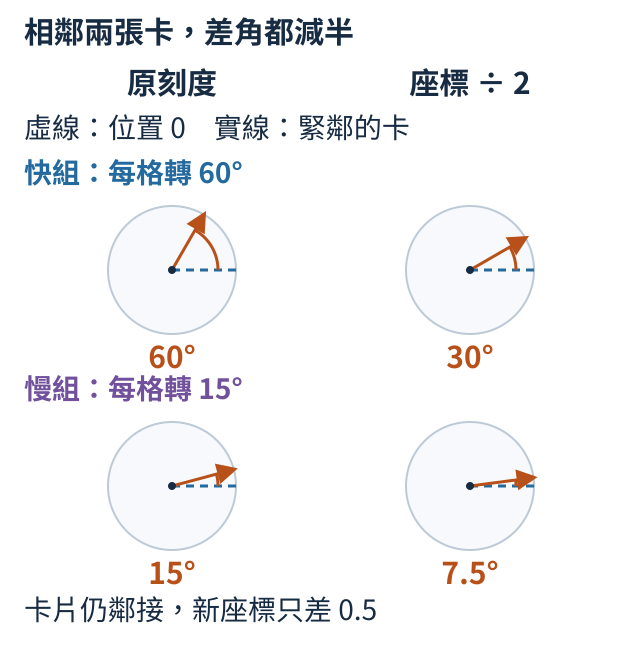

In [2]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/rewrite-14-9-nearby-angles.svg")))

較小差角並沒有把兩張卡變成同一張。它們的文字特徵仍可不同，多組旋轉也會一起提供位置資訊。但模型在訓練中學過的比對關係，可能使用原來的近距離差角；換成更密的刻度後，這些關係需要適應。若為了放進更多文字而縮得更多，近處原有的一格差，在位置數字中就越小。不能只看到最遠的座標變熟悉，就略過近處也被改動了。

快轉和慢轉一起使用，也提供了設計的方向。快轉組在很短的位移內就出現明顯角度變化；慢轉組在較長的範圍仍緩慢改變。單支指針轉完整圈會回到相同方向，所以不能單靠快轉的那一支判斷所有遠近；模型還要結合其他轉速與內容。延長範圍時，可以思考讓某些組保留較多原轉速，而由另一些組承擔較多縮放，而非所有組一律減速。

練習把位置縮放改成除以4，仍比較原位置0與1。先預測兩組差角，再用每格轉角乘0.25核對：快組是15度，慢組是3.75度。下一節的YaRN就從不同轉速應承擔不同縮放開始。

<details>
<summary>回讀與權威來源</summary>

座標與旋轉可回讀[14.1](https://birdhackor.github.io/tiny-perceptron-vlm/14.1.html)。成對旋轉與多組頻率見[RoFormer，arXiv:2104.09864v5，§3.2](https://arxiv.org/pdf/2104.09864v5)；統一插值對不同旋轉組的影響與局部距離取捨，見[YaRN，arXiv:2309.00071v3，§3.1–3.2](https://arxiv.org/pdf/2309.00071v3)。更多查證在[來源筆記](https://github.com/birdhackor/tiny-perceptron-vlm/blob/main/docs/course-revision-20261005/sources/context.md)。本節60度與15度是人為挑選的示意轉速，不是某份模型的實際設定，也沒有訓練或能力成績。

</details>
